In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
 
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBRegressor
from xgboost import plot_importance


In [19]:
apple_csv = "../../../Yahoo_Finance/Apple/AAPL_historical_stock.csv"

df = pd.read_csv(apple_csv)
df


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098207,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093083,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.086251,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.088386,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.090949,73449600
...,...,...,...,...,...,...,...
11497,2026-07-29,339.730011,344.570007,337.350006,338.190002,338.190002,56090800
11498,2026-07-30,333.100006,334.750000,329.589996,333.429993,333.429993,74817800
11499,2026-07-31,304.809998,310.690002,300.000000,308.910004,308.910004,132489100
11500,2026-08-03,309.579987,311.799988,302.559998,303.420013,303.420013,74824300


In [20]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11502 entries, 0 to 11501
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       11502 non-null  str    
 1   Open       11502 non-null  float64
 2   High       11502 non-null  float64
 3   Low        11502 non-null  float64
 4   Close      11502 non-null  float64
 5   Adj Close  11502 non-null  float64
 6   Volume     11502 non-null  int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 629.1 KB


In [21]:
df.isnull().sum()


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [22]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.dropna().reset_index(drop=True)


In [23]:
target = 'Close'
prices = df[[target]].values

In [24]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

In [25]:
PAST = 3
FUTURE = 30

def create_sequences(data, past, future):
    X, y = [], []

    for i in range(len(data) - past - future + 1):
        X.append(data[i : i + past, 0])
        y.append(data[i + past + future - 1, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_prices, PAST, FUTURE)

print("X shape:", X.shape) 
print("y shape:", y.shape)


X shape: (11470, 3)
y shape: (11470,)


In [26]:
# Training and Testing Splits

split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Training Samples: {len(X_train)}, Testing Samples: {len(X_test)}')

Training Samples: 9176, Testing Samples: 2294


In [27]:
model = XGBRegressor(
    n_estimators = 300,
    max_depth = 4,
    learning_rate = 0.05,
    early_stopping_rounds = 10,
    eval_metric = 'rmse'
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose = True
)

[0]	validation_0-rmse:0.45443
[1]	validation_0-rmse:0.45073
[2]	validation_0-rmse:0.44721
[3]	validation_0-rmse:0.44388
[4]	validation_0-rmse:0.44054
[5]	validation_0-rmse:0.43754
[6]	validation_0-rmse:0.43453
[7]	validation_0-rmse:0.43182
[8]	validation_0-rmse:0.42909
[9]	validation_0-rmse:0.42665
[10]	validation_0-rmse:0.42433
[11]	validation_0-rmse:0.42213
[12]	validation_0-rmse:0.41989
[13]	validation_0-rmse:0.41791
[14]	validation_0-rmse:0.41602
[15]	validation_0-rmse:0.41409
[16]	validation_0-rmse:0.41239
[17]	validation_0-rmse:0.41065
[18]	validation_0-rmse:0.40899
[19]	validation_0-rmse:0.40742
[20]	validation_0-rmse:0.40593
[21]	validation_0-rmse:0.40451
[22]	validation_0-rmse:0.40316
[23]	validation_0-rmse:0.40194
[24]	validation_0-rmse:0.40078
[25]	validation_0-rmse:0.39962
[26]	validation_0-rmse:0.39851
[27]	validation_0-rmse:0.39752
[28]	validation_0-rmse:0.39652
[29]	validation_0-rmse:0.39557
[30]	validation_0-rmse:0.39466
[31]	validation_0-rmse:0.39385
[32]	validation_0-

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100


print(f'RMSE: ${rmse:.2f}, MAE ${mae:.2f}, MAPE: {mape:.2f}%')

RMSE: $0.38, MAE $0.30, MAPE: 60.09%


In [29]:
final_model = XGBRegressor(
    n_estimators = model.best_iteration,
    max_depth = 4,
    learning_rate = 0.05
)
final_model.fit(X, y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
os.makedirs('export', exist_ok=True)
joblib.dump(final_model, 'export/apple_xgb_model.pkl')

['export/apple_xgb_model.pkl']

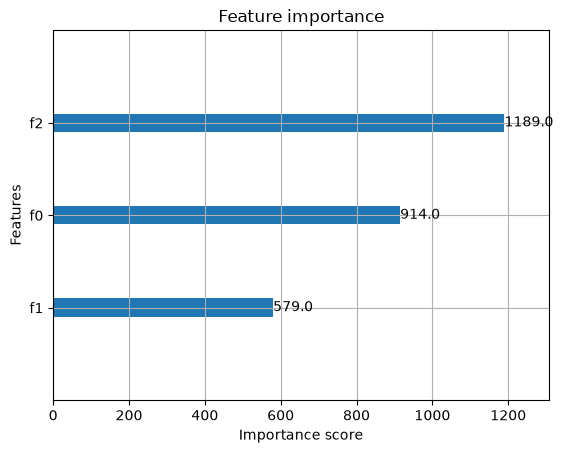

In [31]:
plot_importance(model)
plt.show()